In [17]:
# Cell 1: imports + load package

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import welch, coherence, csd

data = np.load("./data/full_analysis_package_10.npz")

source = data["source"]
source_rep = data["source_rep"]

error = data["error"]
ref = data["ref"]

error_nc = data["error_nc"]
ref_nc = data["ref_nc"]

w_norm_log = data["w_norm_log"]
weights = data["weights"]

error_ir = data["error_ir"]
ref_ir = data["ref_ir"]

error_ir_raw = data["error_ir_raw"]
ref_ir_raw = data["ref_ir_raw"]

fs = float(data["fs"])

mu = float(data["mu"])
cancel_gain = float(data["cancel_gain"])
leak = float(data["leak"])
lag = int(data["lag"])
eps = float(data["eps"])

ref_threshold = float(data["ref_threshold"])
mavg_tau_ms = float(data["mavg_tau_ms"])
update_sign = float(data["update_sign"])

max_step = float(data["max_step"])
min_xnorm = float(data["min_xnorm"])
max_control = float(data["max_control"])

n_repeats = int(data["n_repeats"])
ir_len = int(data["ir_len"])
panel_to_error_cm = float(data["panel_to_error_cm"])

print(f"fs = {fs:.0f} Hz")
print(f"weights = {len(weights)} taps")
print(f"IR length = {ir_len}")
print(f"lag = {lag}")
print(f"cancel_gain = {cancel_gain}")
print(f"mu = {mu}")
print(f"leak = {leak}")
print(f"max_control = {max_control}")

fs = 96000 Hz
weights = 1024 taps
IR length = 256
lag = 86
cancel_gain = 0.11
mu = 0.00325
leak = 0.0
max_control = 0.0880552


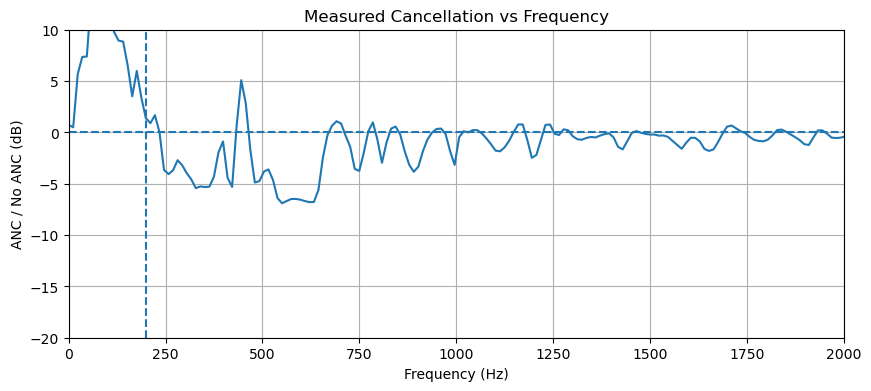

In [18]:
# Cell 2: measured cancellation vs frequency

NPERSEG = 8192

f, P_cancel = welch(
    error,
    fs=fs,
    nperseg=NPERSEG,
)

_, P_no_cancel = welch(
    error_nc,
    fs=fs,
    nperseg=NPERSEG,
)

reduction_db = 10 * np.log10(
    (P_cancel + 1e-30) /
    (P_no_cancel + 1e-30)
)

plt.figure(figsize=(10, 4))

plt.plot(f, reduction_db)

plt.axhline(0, linestyle="--")
plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-20, 10)

plt.xlabel("Frequency (Hz)")
plt.ylabel("ANC / No ANC (dB)")
plt.title("Measured Cancellation vs Frequency")
plt.grid()

plt.show()

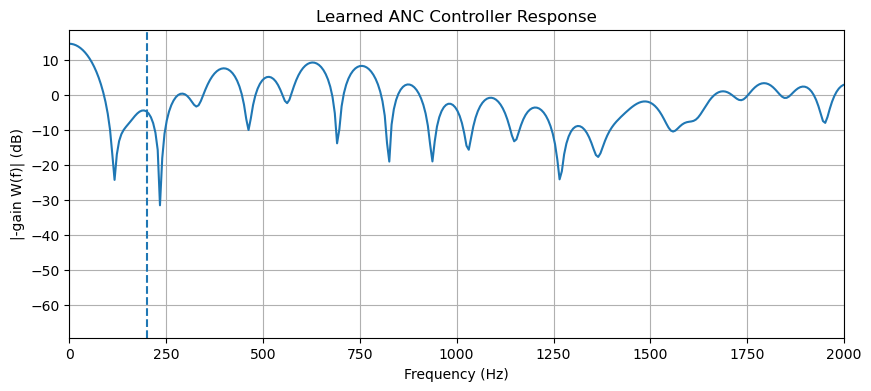

In [19]:
# Cell 3: learned controller frequency response

NFFT = 16384

f_fft = np.fft.rfftfreq(NFFT, 1 / fs)

W = np.fft.rfft(weights, n=NFFT)

W_control = -cancel_gain * W

W_db = 20 * np.log10(
    np.abs(W_control) + 1e-30
)

plt.figure(figsize=(10, 4))

plt.plot(f_fft, W_db)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("|-gain W(f)| (dB)")
plt.title("Learned ANC Controller Response")
plt.grid()

plt.show()

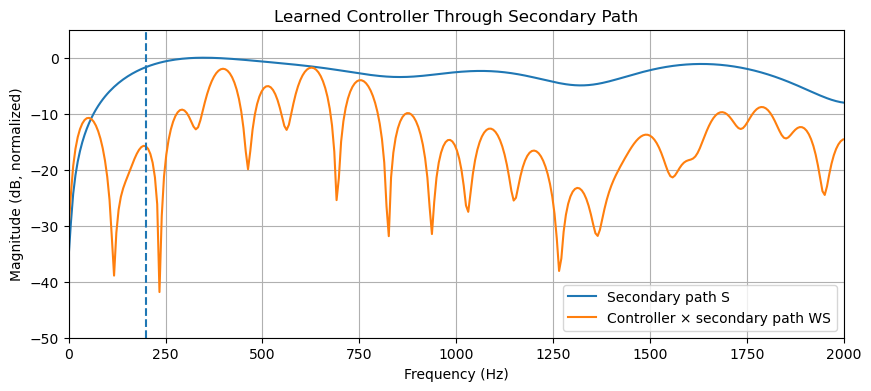

In [20]:
# Cell 4: controller after secondary path

S = np.fft.rfft(error_ir, n=NFFT)

WS = W_control * S

S_db = 20 * np.log10(
    np.abs(S) + 1e-30
)

WS_db = 20 * np.log10(
    np.abs(WS) + 1e-30
)

# Normalize separately for shape comparison
S_db_norm = S_db - np.max(S_db)
WS_db_norm = WS_db - np.max(WS_db)

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    S_db_norm,
    label="Secondary path S"
)

plt.plot(
    f_fft,
    WS_db_norm,
    label="Controller × secondary path WS"
)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-50, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB, normalized)")
plt.title("Learned Controller Through Secondary Path")
plt.grid()
plt.legend()

plt.show()

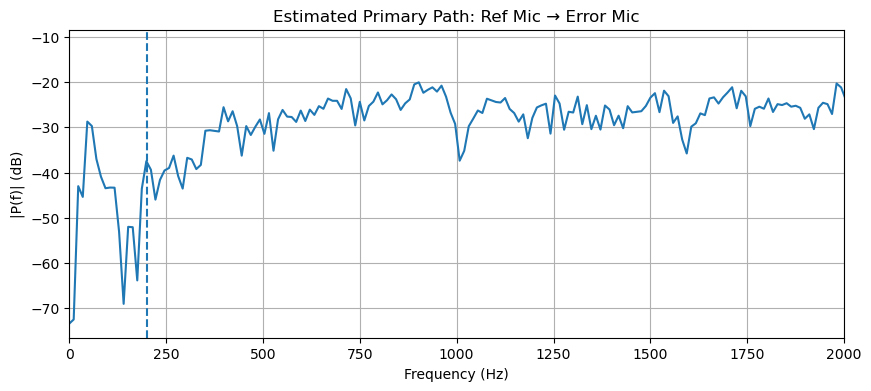

In [21]:
# Cell 5: estimate primary path, ref mic -> error mic

f_tf, S_er = csd(
    error_nc,
    ref_nc,
    fs=fs,
    nperseg=NPERSEG,
)

_, S_rr = welch(
    ref_nc,
    fs=fs,
    nperseg=NPERSEG,
)

P_est = S_er / (S_rr + 1e-30)

P_db = 20 * np.log10(
    np.abs(P_est) + 1e-30
)

plt.figure(figsize=(10, 4))

plt.plot(f_tf, P_db)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("|P(f)| (dB)")
plt.title("Estimated Primary Path: Ref Mic → Error Mic")
plt.grid()

plt.show()

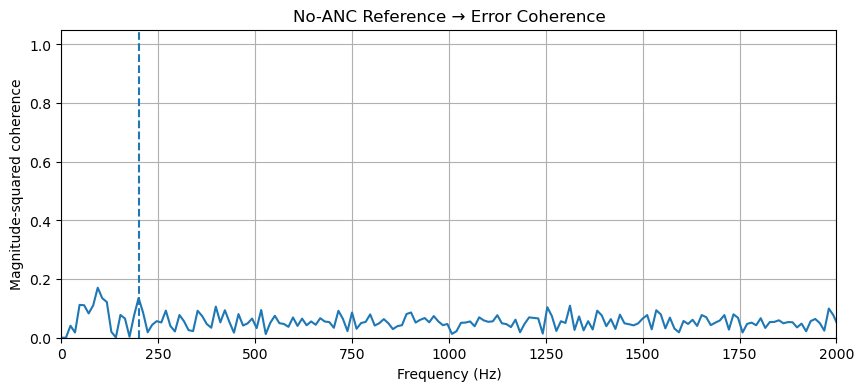

In [22]:
# Cell 6: ref-mic -> error-mic coherence

f_coh, coh = coherence(
    ref_nc,
    error_nc,
    fs=fs,
    nperseg=NPERSEG,
)

plt.figure(figsize=(10, 4))

plt.plot(f_coh, coh)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(0, 1.05)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude-squared coherence")
plt.title("No-ANC Reference → Error Coherence")
plt.grid()

plt.show()

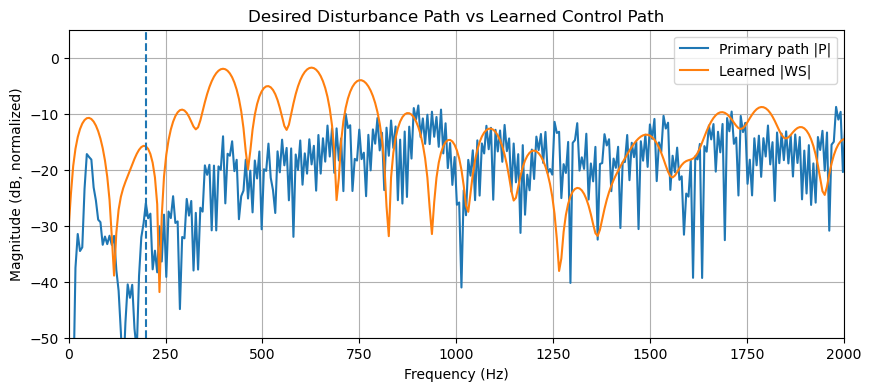

In [23]:
# Cell 7: compare desired primary cancellation shape vs learned WS

# Interpolate P_est onto FFT frequency grid
P_interp_real = np.interp(
    f_fft,
    f_tf,
    np.real(P_est)
)

P_interp_imag = np.interp(
    f_fft,
    f_tf,
    np.imag(P_est)
)

P_interp = P_interp_real + 1j * P_interp_imag

P_mag_db = 20 * np.log10(
    np.abs(P_interp) + 1e-30
)

WS_mag_db = 20 * np.log10(
    np.abs(WS) + 1e-30
)

# normalize for shape comparison
P_mag_db_norm = P_mag_db - np.max(P_mag_db)
WS_mag_db_norm = WS_mag_db - np.max(WS_mag_db)

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    P_mag_db_norm,
    label="Primary path |P|"
)

plt.plot(
    f_fft,
    WS_mag_db_norm,
    label="Learned |WS|"
)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-50, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB, normalized)")
plt.title("Desired Disturbance Path vs Learned Control Path")
plt.grid()
plt.legend()

plt.show()

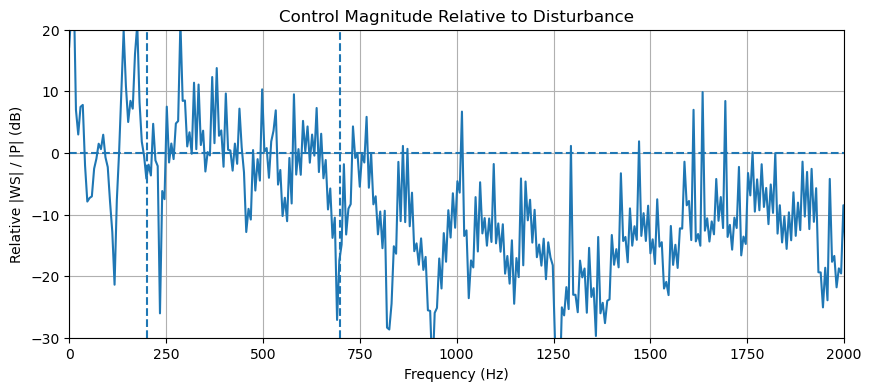

In [24]:
# Cell 8: relative control magnitude vs disturbance

mag_ratio_db = 20 * np.log10(
    (np.abs(WS) + 1e-30) /
    (np.abs(P_interp) + 1e-30)
)

# Normalize using median ratio in successful ANC band
good_band = (
    (f_fft >= 300) &
    (f_fft <= 700)
)

offset = np.median(
    mag_ratio_db[good_band]
)

mag_ratio_db_rel = mag_ratio_db - offset

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    mag_ratio_db_rel
)

plt.axhline(0, linestyle="--")
plt.axvline(200, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-30, 20)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative |WS| / |P| (dB)")
plt.title("Control Magnitude Relative to Disturbance")
plt.grid()

plt.show()

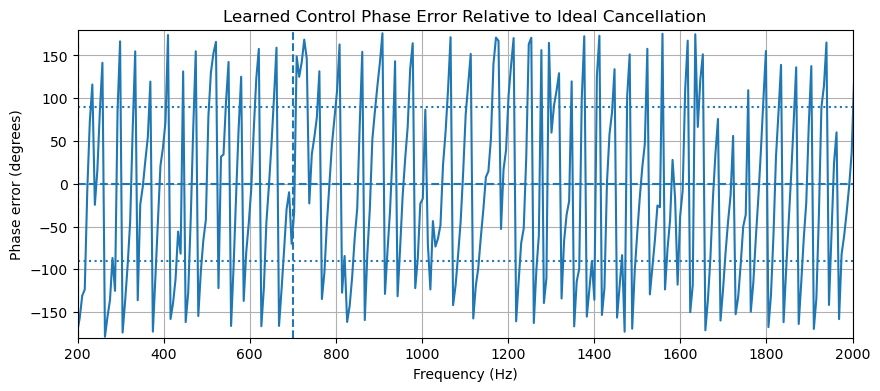

In [25]:
# Cell 9: controller phase error relative to ideal cancellation

phase_error = np.angle(
    WS / (-P_interp + 1e-30)
)

phase_error_deg = np.degrees(
    phase_error
)

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    phase_error_deg
)

plt.axhline(0, linestyle="--")
plt.axhline(90, linestyle=":")
plt.axhline(-90, linestyle=":")

plt.axvline(200, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(200, 2000)
plt.ylim(-180, 180)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase error (degrees)")
plt.title("Learned Control Phase Error Relative to Ideal Cancellation")
plt.grid()

plt.show()

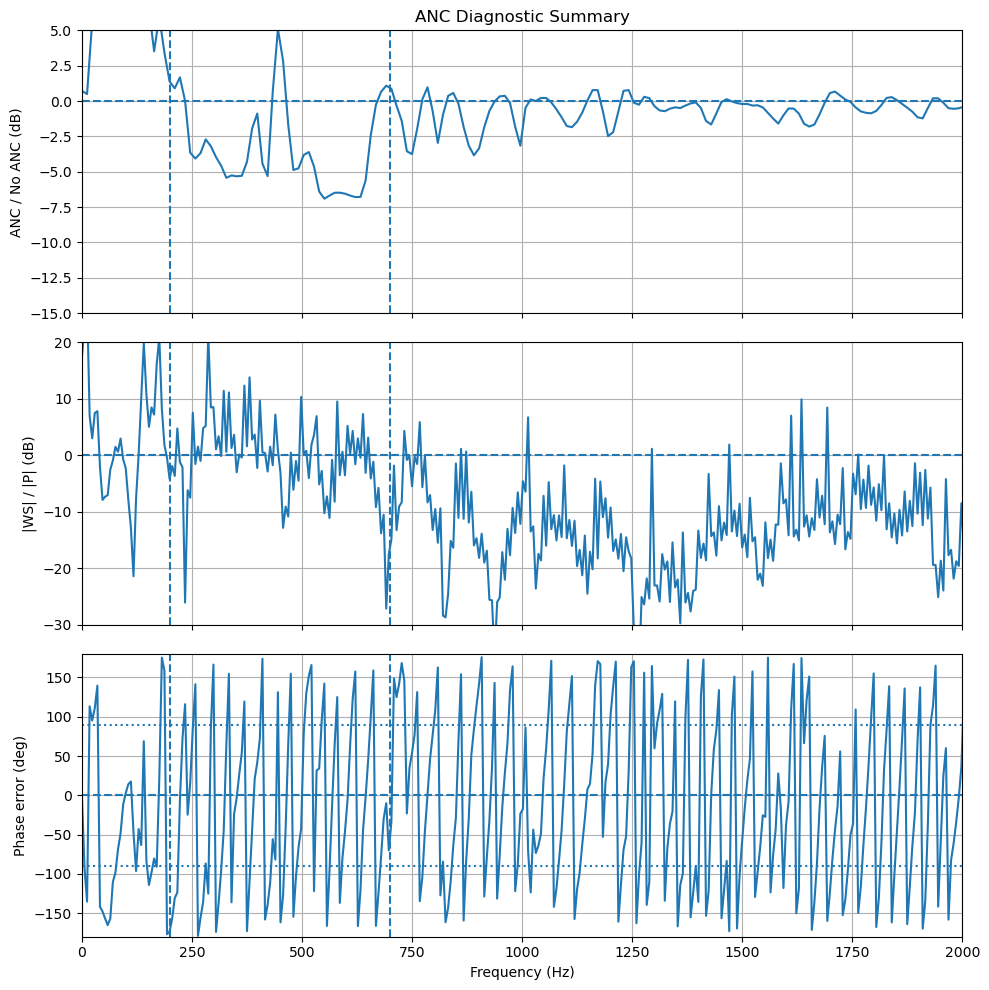

In [26]:
# Cell 10: combined diagnostic

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 10),
    sharex=True
)

# measured cancellation
axes[0].plot(
    f,
    reduction_db
)

axes[0].axhline(0, linestyle="--")
axes[0].set_ylabel("ANC / No ANC (dB)")
axes[0].set_ylim(-15, 5)
axes[0].grid()
axes[0].set_title("ANC Diagnostic Summary")

# relative magnitude
axes[1].plot(
    f_fft,
    mag_ratio_db_rel
)

axes[1].axhline(0, linestyle="--")
axes[1].set_ylabel("|WS| / |P| (dB)")
axes[1].set_ylim(-30, 20)
axes[1].grid()

# phase error
axes[2].plot(
    f_fft,
    phase_error_deg
)

axes[2].axhline(0, linestyle="--")
axes[2].axhline(90, linestyle=":")
axes[2].axhline(-90, linestyle=":")

axes[2].set_ylabel("Phase error (deg)")
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylim(-180, 180)
axes[2].grid()

for ax in axes:
    ax.axvline(200, linestyle="--")
    ax.axvline(700, linestyle="--")
    ax.set_xlim(0, 2000)

plt.tight_layout()
plt.show()

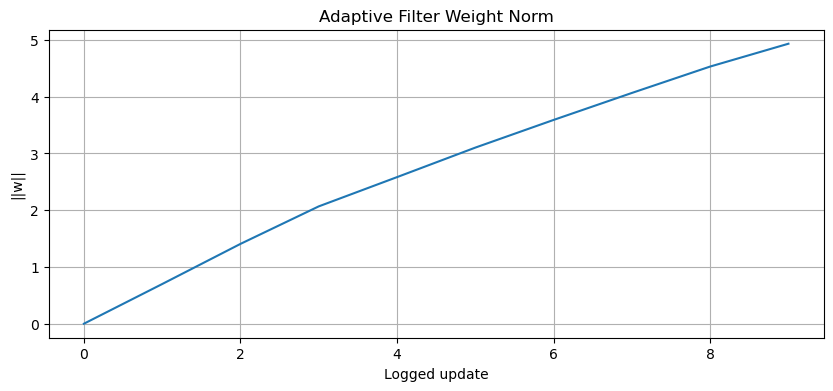

In [27]:
# Cell 11: weight norm evolution

plt.figure(figsize=(10, 4))

plt.plot(w_norm_log)

plt.xlabel("Logged update")
plt.ylabel("||w||")
plt.title("Adaptive Filter Weight Norm")
plt.grid()

plt.show()

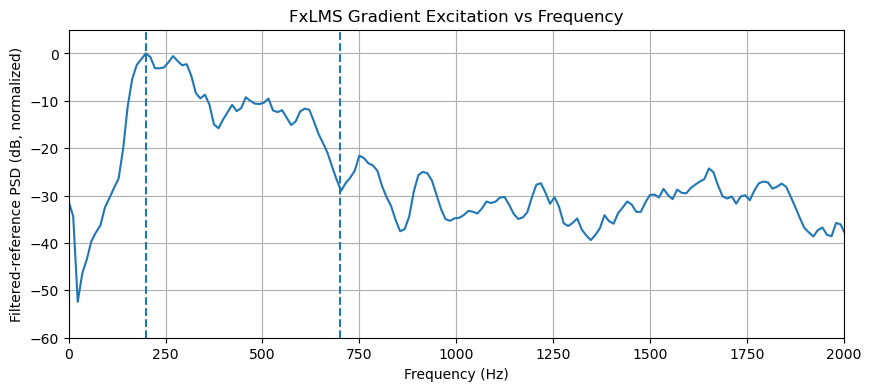

In [28]:
from scipy.signal import welch, fftconvolve
import numpy as np
import matplotlib.pyplot as plt

# Use no-ANC reference so there is no controller feedback contaminating it
xf_nc = fftconvolve(ref_nc, error_ir, mode="full")[:len(ref_nc)]

f_xf, P_xf = welch(
    xf_nc,
    fs=fs,
    nperseg=8192,
)

P_xf_db = 10 * np.log10(P_xf + 1e-30)
P_xf_db -= np.max(P_xf_db)

plt.figure(figsize=(10, 4))
plt.plot(f_xf, P_xf_db)

plt.axvline(200, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-60, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Filtered-reference PSD (dB, normalized)")
plt.title("FxLMS Gradient Excitation vs Frequency")
plt.grid()
plt.show()

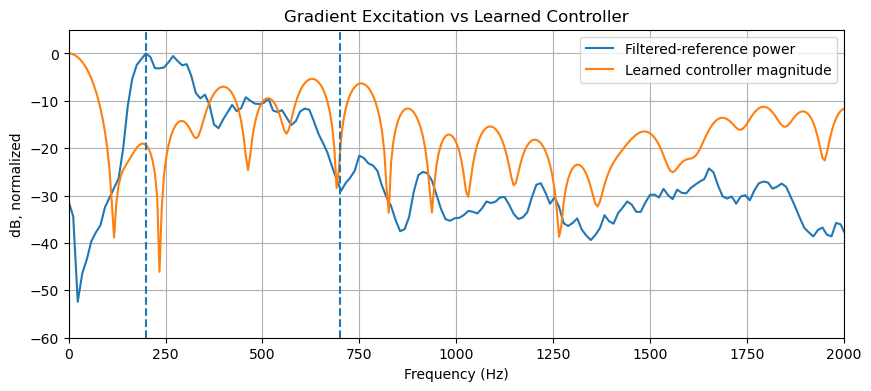

In [29]:
# interpolate filtered-reference PSD onto FFT frequencies
P_xf_interp = np.interp(
    f_fft,
    f_xf,
    P_xf_db,
)

W_plot = 20 * np.log10(np.abs(W_control) + 1e-30)
W_plot -= np.max(W_plot)

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    P_xf_interp,
    label="Filtered-reference power"
)

plt.plot(
    f_fft,
    W_plot,
    label="Learned controller magnitude"
)

plt.axvline(200, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-60, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("dB, normalized")
plt.title("Gradient Excitation vs Learned Controller")
plt.grid()
plt.legend()
plt.show()

In [30]:
data_5 = np.load("./data/full_analysis_package.npz")

source_5 = data["source"]
source_rep_5 = data["source_rep"]

error_5 = data["error"]
ref_5 = data["ref"]

error_nc_5 = data["error_nc"]
ref_nc_5 = data["ref_nc"]

w_norm_log_5 = data["w_norm_log"]
weights_5 = data["weights"]

error_ir_5 = data["error_ir"]
ref_ir_5 = data["ref_ir"]

error_ir_raw_5 = data["error_ir_raw"]
ref_ir_raw_5 = data["ref_ir_raw"]

fs_5 = float(data["fs"])

mu_5 = float(data["mu"])
cancel_gain_5 = float(data["cancel_gain"])
leak_5 = float(data["leak"])
lag_5 = int(data["lag"])
eps_5 = float(data["eps"])

ref_threshold_5 = float(data["ref_threshold"])
mavg_tau_ms_5 = float(data["mavg_tau_ms"])
update_sign_5 = float(data["update_sign"])

max_step_5 = float(data["max_step"])
min_xnorm_5 = float(data["min_xnorm"])
max_control_5 = float(data["max_control"])

n_repeats_5 = int(data["n_repeats"])
ir_len_5 = int(data["ir_len"])
panel_to_error_cm_5 = float(data["panel_to_error_cm"])

print(f"fs = {fs:.0f} Hz")
print(f"weights = {len(weights)} taps")
print(f"IR length = {ir_len}")
print(f"lag = {lag}")
print(f"cancel_gain = {cancel_gain}")
print(f"mu = {mu}")
print(f"leak = {leak}")
print(f"max_control = {max_control}")

fs = 96000 Hz
weights = 1024 taps
IR length = 256
lag = 86
cancel_gain = 0.11
mu = 0.00325
leak = 0.0
max_control = 0.0880552


In [36]:
n_repeats_5

10

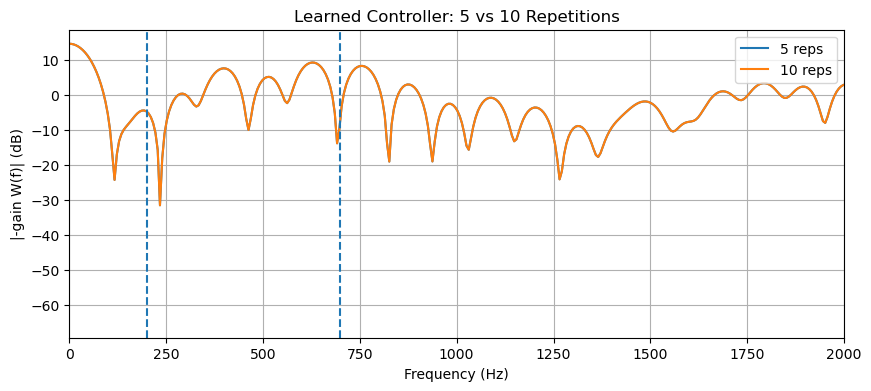

In [31]:
# Compare 5-rep vs 10-rep learned controller
weights_10 = weights

NFFT = 16384

f_fft = np.fft.rfftfreq(NFFT, 1/fs)

W5 = -cancel_gain * np.fft.rfft(weights_5, n=NFFT)
W10 = -cancel_gain * np.fft.rfft(weights_10, n=NFFT)

W5_db = 20 * np.log10(np.abs(W5) + 1e-30)
W10_db = 20 * np.log10(np.abs(W10) + 1e-30)

plt.figure(figsize=(10, 4))

plt.plot(f_fft, W5_db, label="5 reps")
plt.plot(f_fft, W10_db, label="10 reps")

plt.axvline(200, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("|-gain W(f)| (dB)")
plt.title("Learned Controller: 5 vs 10 Repetitions")
plt.grid()
plt.legend()

plt.show()

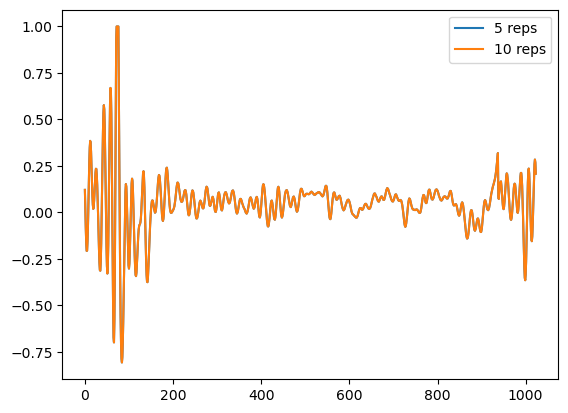

In [32]:
plt.plot(weights_5, label="5 reps")
plt.plot(weights_10, label="10 reps")
plt.legend()

In [35]:
w_norm_log_5

array([0.        , 0.69924009, 1.40678121, 2.0679342 , 2.58357494,
       3.10361034, 3.5914182 , 4.06701865, 4.53236488, 4.93472091])

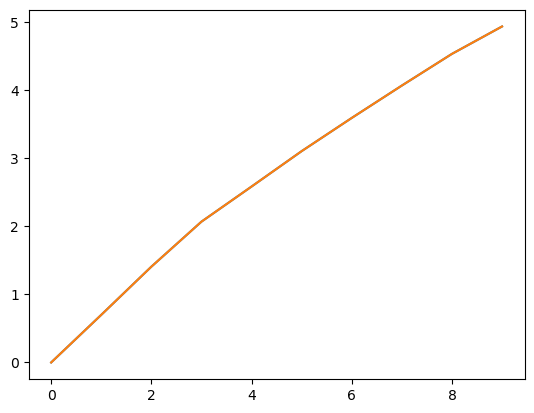

In [33]:
plt.plot(w_norm_log_5)
plt.plot(w_norm_log)

In [51]:
data = np.load("./data/full_analysis_package.npz")

error_nc = data["error_nc"]
ref_nc = data["ref_nc"]
error = data["error"]
ref = data["ref"]

weights = data["weights"]

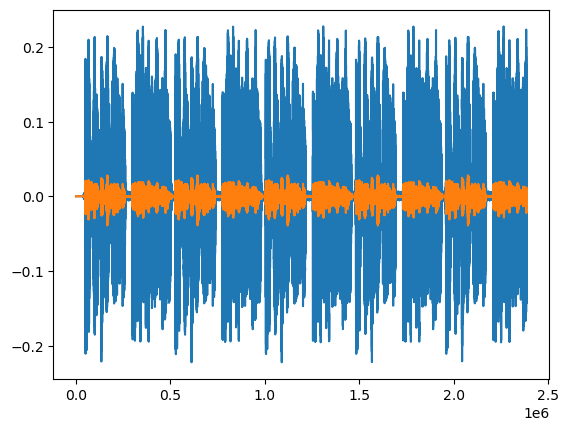

In [45]:
# error_nc = error_nc[:len(ref_nc)]
plt.plot(ref_nc)
plt.plot(error_nc)


Delay: 86 samples
Lambda: 0.01
Train: -20.04 dB
Test:  -19.93 dB
Norm:  1.7208


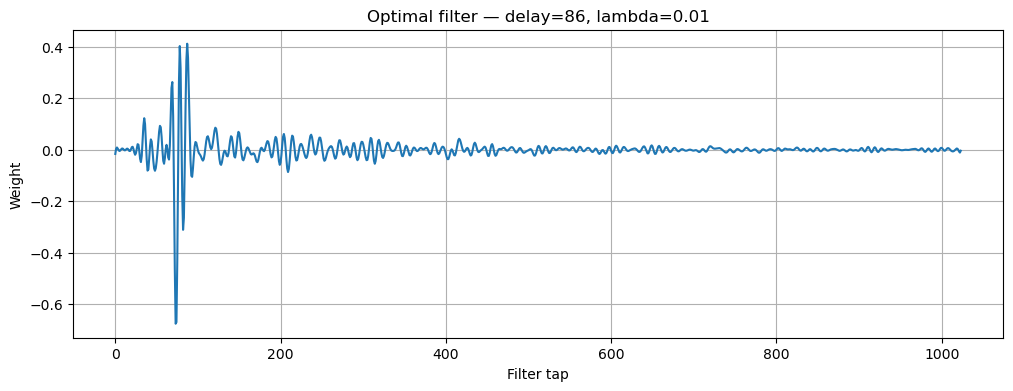

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

error_nc = error_nc[:len(ref_nc)]
M = len(weights)
delay = 86
lam = 1e-2

# Use the same amount of each recording
N = min(len(error_nc), len(ref_nc))
error = error_nc[:N].astype(np.float64)
ref   = ref_nc[:N].astype(np.float64)


# ---------------------------------------------------------
# 1. Reference through secondary path
# ---------------------------------------------------------

xf = fftconvolve(ref, error_ir, mode="full")[:N]


# ---------------------------------------------------------
# 2. Add the unavoidable 86-sample SHARC delay
# ---------------------------------------------------------

xf_delayed = np.zeros_like(xf)
xf_delayed[delay:] = xf[:-delay]


# ---------------------------------------------------------
# 3. Construct FIR regression matrix
#
# X @ w = predicted contribution from panel at error mic
# ---------------------------------------------------------

X = np.zeros((N - M + 1, M), dtype=np.float64)

for k in range(M):
    X[:, k] = xf_delayed[M - 1 - k : N - k]

d = error[M - 1:]


# ---------------------------------------------------------
# 4. Train/test split
# ---------------------------------------------------------

split = len(d) // 2

X_train = X[:split]
d_train = d[:split]

X_test = X[split:]
d_test = d[split:]


# ---------------------------------------------------------
# 5. Ridge least squares
#
# minimize ||d + Xw||^2 + lambda ||w||^2
# ---------------------------------------------------------

A = X_train.T @ X_train
b = X_train.T @ (-d_train)

w_delay86 = np.linalg.solve(
    A + lam * np.eye(M),
    b
)


# ---------------------------------------------------------
# 6. Evaluate
# ---------------------------------------------------------

train_residual = d_train + X_train @ w_delay86
test_residual  = d_test  + X_test @ w_delay86

train_db = 10 * np.log10(
    np.mean(train_residual**2) /
    np.mean(d_train**2)
)

test_db = 10 * np.log10(
    np.mean(test_residual**2) /
    np.mean(d_test**2)
)

print(f"Delay: {delay} samples")
print(f"Lambda: {lam}")
print(f"Train: {train_db:.2f} dB")
print(f"Test:  {test_db:.2f} dB")
print(f"Norm:  {np.linalg.norm(w_delay86):.4f}")


# ---------------------------------------------------------
# 7. Plot
# ---------------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(w_delay86)
plt.xlabel("Filter tap")
plt.ylabel("Weight")
plt.title(f"Optimal filter — delay={delay}, lambda={lam:g}")
plt.grid()
plt.show()

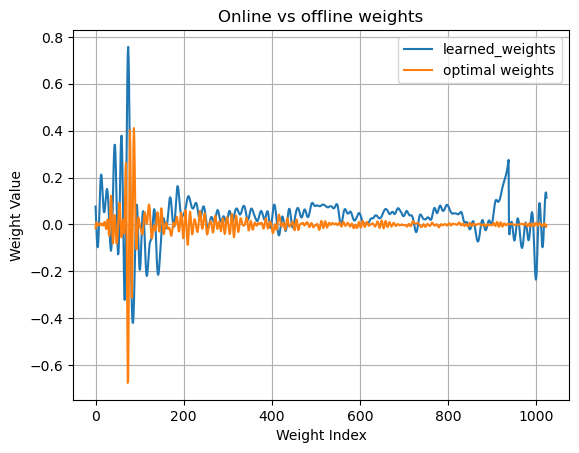

In [49]:
plt.plot(weights, label="learned_weights")
plt.plot(w_delay86, label="optimal weights")
plt.title(f"Online vs offline weights")
plt.xlabel("Weight Index")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.show()


In [50]:
from pathlib import Path

path = Path(r'..\sharc\reverb\reverb_core1\src\filter_seed.h')

path.parent.mkdir(parents=True, exist_ok=True)

with path.open("w") as f:
    f.write("#pragma once\n\n")

    f.write(f"#define SEED_LEN {len(w_delay86)}\n\n")

    f.write("static const float seed[SEED_LEN] = {\n")
    for v in w_delay86:
        f.write(f"    {float(v):.9e}f,\n")
    f.write("};\n\n")

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve, welch

fs = 96_000

x = np.asarray(ref, dtype=np.float64)
s = np.asarray(error_ir, dtype=np.float64)

# Same signal conceptually used for the FxLMS gradient
xf = fftconvolve(x, s, mode="full")[:len(x)]

print("RMS ref:", np.sqrt(np.mean(x**2)))
print("RMS xf: ", np.sqrt(np.mean(xf**2)))

RMS ref: 0.05965077313418166
RMS xf:  0.01489825511350189


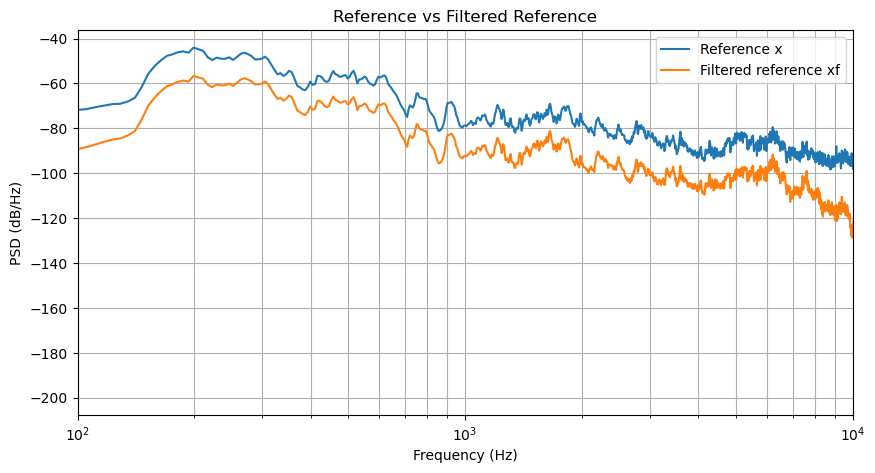

In [53]:
nperseg = 16384

f, P_ref = welch(
    x,
    fs=fs,
    nperseg=nperseg,
)

_, P_xf = welch(
    xf,
    fs=fs,
    nperseg=nperseg,
)

eps = 1e-20

plt.figure(figsize=(10, 5))

plt.semilogx(f, 10*np.log10(P_ref + eps), label="Reference x")
plt.semilogx(f, 10*np.log10(P_xf + eps), label="Filtered reference xf")

plt.xlim(100, 10000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("Reference vs Filtered Reference")
plt.grid(True, which="both")
plt.legend()
plt.show()

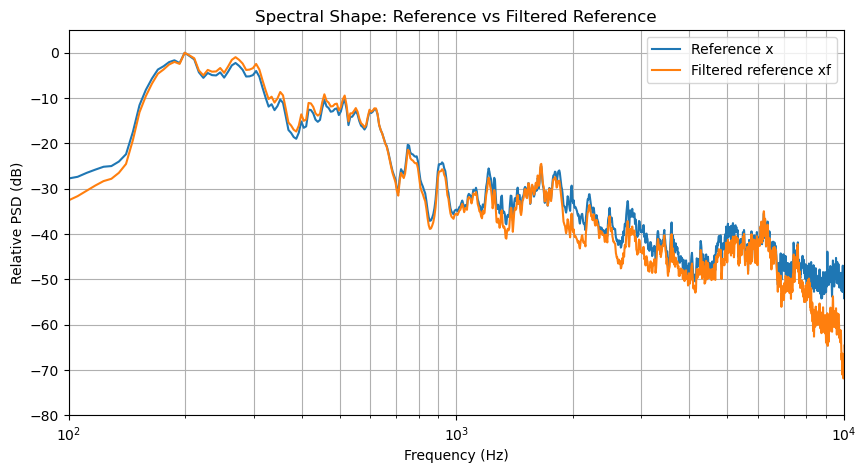

In [54]:
P_ref_db = 10*np.log10(P_ref + eps)
P_xf_db  = 10*np.log10(P_xf + eps)

P_ref_db -= np.max(P_ref_db)
P_xf_db  -= np.max(P_xf_db)

plt.figure(figsize=(10, 5))

plt.semilogx(f, P_ref_db, label="Reference x")
plt.semilogx(f, P_xf_db, label="Filtered reference xf")

plt.xlim(100, 10000)
plt.ylim(-80, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative PSD (dB)")
plt.title("Spectral Shape: Reference vs Filtered Reference")
plt.grid(True, which="both")
plt.legend()
plt.show()

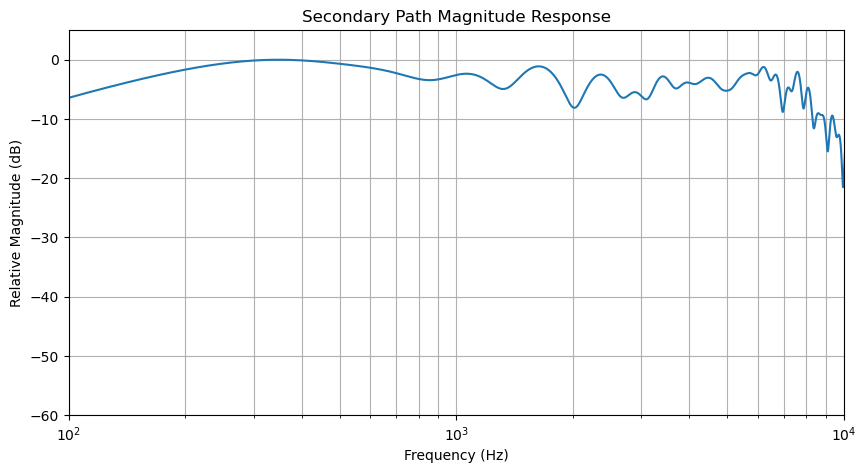

In [55]:
from scipy.signal import freqz

f_ir, H = freqz(error_ir, worN=16384, fs=fs)

H_db = 20*np.log10(np.abs(H) + 1e-12)
H_db -= np.max(H_db)

plt.figure(figsize=(10, 5))
plt.semilogx(f_ir, H_db)

plt.xlim(100, 10000)
plt.ylim(-60, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative Magnitude (dB)")
plt.title("Secondary Path Magnitude Response")
plt.grid(True, which="both")
plt.show()

In [57]:
bands = [
    (0, 200),
    (200, 300),
    (300, 700),
    (700, 1000),
    (1000, 2000),
    (2000, 5000),
    (5000, 10000),
]

def band_power(f, P, lo, hi):
    mask = (f >= lo) & (f < hi)
    return np.trapezoid(P[mask], f[mask])

print(f"{'Band':>15} {'Ref power':>15} {'xf power':>15} {'xf/ref':>12}")

for lo, hi in bands:
    pr = band_power(f, P_ref, lo, hi)
    pf = band_power(f, P_xf, lo, hi)

    ratio_db = 10*np.log10((pf + 1e-30)/(pr + 1e-30))

    print(
        f"{lo:5d}-{hi:<5d} Hz "
        f"{pr:15.3e} "
        f"{pf:15.3e} "
        f"{ratio_db:10.2f} dB"
    )

           Band       Ref power        xf power       xf/ref
    0-200   Hz       8.917e-04       4.276e-05     -13.19 dB
  200-300   Hz       1.528e-03       1.036e-04     -11.69 dB
  300-700   Hz       7.541e-04       5.393e-05     -11.46 dB
  700-1000  Hz       2.690e-05       1.078e-06     -13.97 dB
 1000-2000  Hz       3.500e-05       1.470e-06     -13.77 dB
 2000-5000  Hz       1.218e-05       3.326e-07     -15.64 dB
 5000-10000 Hz       7.350e-06       2.674e-07     -14.39 dB


In [58]:
from numpy.lib.stride_tricks import sliding_window_view

M = 1024

# Use e.g. 2 seconds
N = min(len(xf), 2 * fs)

xf_seg = xf[:N]

# Each row is one M-sample filtered-reference vector
X = sliding_window_view(xf_seg, M)

# Subsample rows so this stays cheap
X = X[::10]

print("X shape:", X.shape)

# Remove mean
X = X - X.mean(axis=0, keepdims=True)

# Autocorrelation/covariance matrix
R = (X.T @ X) / X.shape[0]

print("R shape:", R.shape)

X shape: (19098, 1024)
R shape: (1024, 1024)


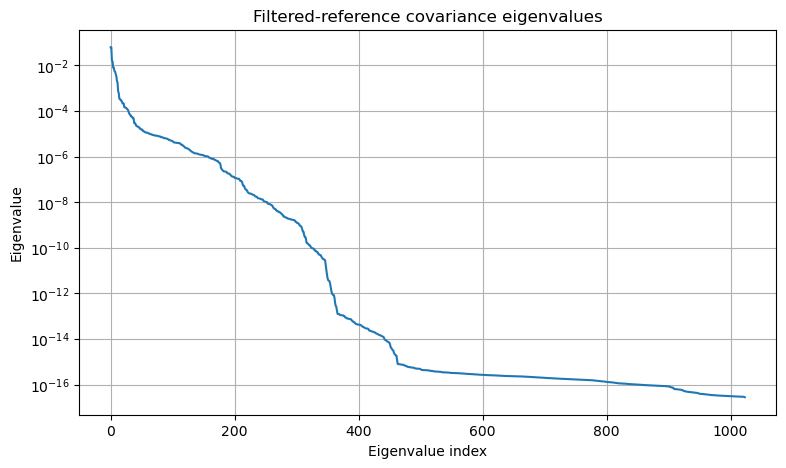

Largest eigenvalue: 0.06244133139277657
Smallest retained eigenvalue: 6.432091562482992e-14
Condition number: 970778024320.7893
Number retained: 390


In [59]:
eigvals = np.linalg.eigvalsh(R)

# Largest first
eigvals = eigvals[::-1]

plt.figure(figsize=(9, 5))
plt.semilogy(eigvals + 1e-30)

plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.title("Filtered-reference covariance eigenvalues")
plt.grid(True)
plt.show()

positive = eigvals[eigvals > eigvals[0] * 1e-12]

print("Largest eigenvalue:", positive[0])
print("Smallest retained eigenvalue:", positive[-1])
print("Condition number:", positive[0] / positive[-1])
print("Number retained:", len(positive))

In [62]:
ir = data["error_ir_raw"]
source = data["source"]
len(ir), len(source)

(1535999, 477668)

Raw IR length: 1535999
Source length: 477668
NFFT: 2097152
Frequency resolution: 0.0457763671875 Hz

Original raw peak: 619220
Acoustic delay: 13
Crop start: 619207
EE IR length: 256


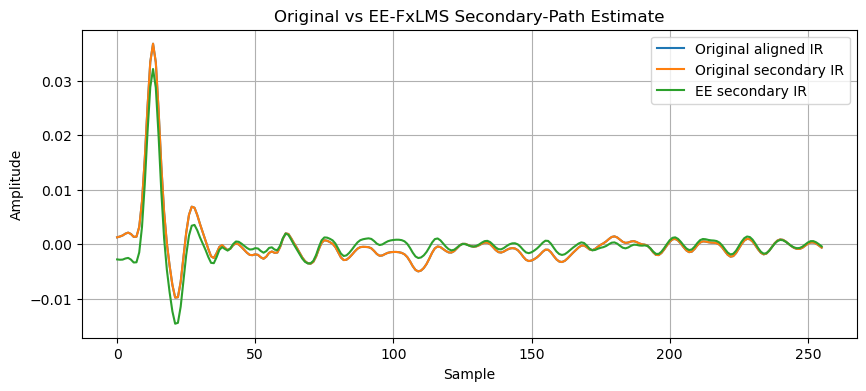

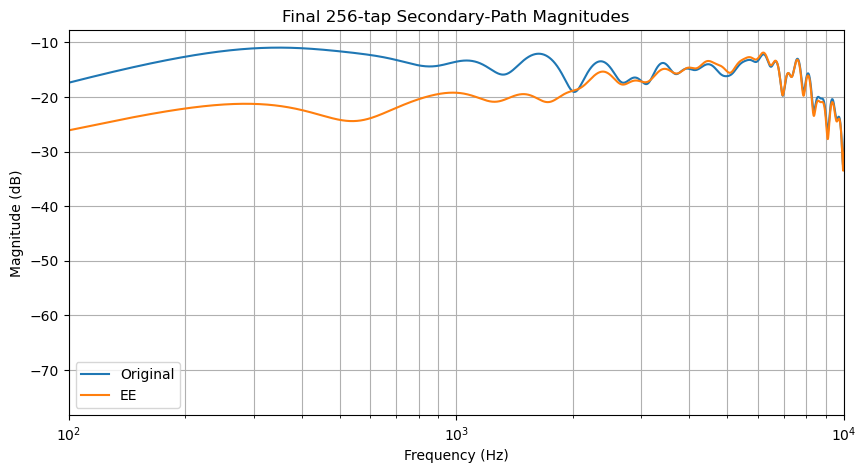

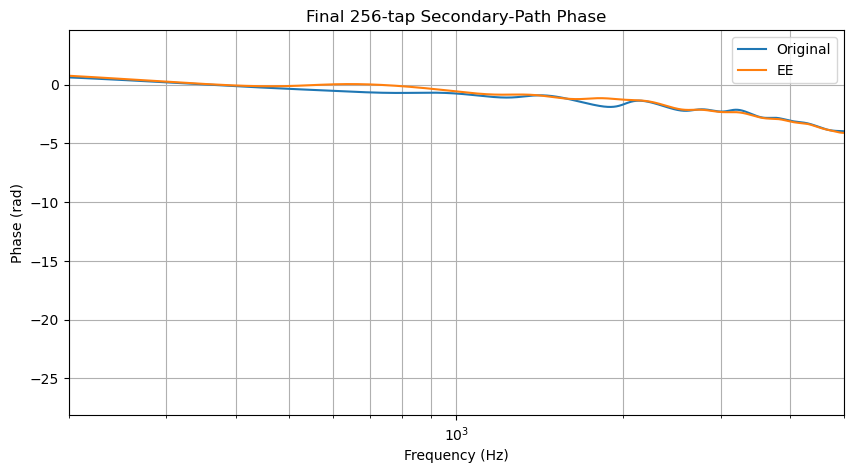

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


# ------------------------------------------------------------
# Inputs
# ------------------------------------------------------------

ir = np.asarray(data["error_ir_raw"], dtype=np.float64)
source = np.asarray(data["source"], dtype=np.float64)

fs = 96_000
ir_len = 256
distance_cm = 4.5

# Frequency region we actually want to equalize
f_low = 200
f_high = 5_000


# ------------------------------------------------------------
# 1. Common FFT length
# ------------------------------------------------------------

NFFT = 1 << int(np.ceil(np.log2(max(len(ir), len(source)))))

print("Raw IR length:", len(ir))
print("Source length:", len(source))
print("NFFT:", NFFT)
print("Frequency resolution:", fs / NFFT, "Hz")


# ------------------------------------------------------------
# 2. FFT of raw secondary-path IR and source
# ------------------------------------------------------------

S = np.fft.rfft(ir, n=NFFT)
X = np.fft.rfft(source, n=NFFT)

freqs = np.fft.rfftfreq(NFFT, d=1/fs)

S_mag = np.abs(S)
S_phase = np.angle(S)

X_mag = np.abs(X)


# ------------------------------------------------------------
# 3. Smooth the source spectral magnitude
#
# We don't want to invert every tiny FFT notch.
# Smooth in frequency before taking 1 / |X|.
# ------------------------------------------------------------

X_mag_smooth = gaussian_filter1d(
    X_mag,
    sigma=50
)


# ------------------------------------------------------------
# 4. Define frequency region of interest
# ------------------------------------------------------------

band = (freqs >= f_low) & (freqs <= f_high)


# ------------------------------------------------------------
# 5. Floor the source magnitude
#
# Prevent tiny values of |X| from causing enormous boosts.
#
# Here we're not allowing values below 5% of the maximum
# source magnitude within the control band.
# ------------------------------------------------------------

floor = 0.05 * np.max(X_mag_smooth[band])

X_safe = np.maximum(
    X_mag_smooth,
    floor
)


# ------------------------------------------------------------
# 6. Desired EE-FxLMS magnitude
#
# Case 2 from the paper:
#
#       |S_EE(f)| ∝ 1 / |X(f)|
#
# First construct the inverse weighting.
# ------------------------------------------------------------

inverse_X = 1.0 / X_safe


# ------------------------------------------------------------
# 7. Scale it to a sensible overall level
#
# Absolute magnitude isn't the important part here.
# We preserve roughly the median magnitude of the original
# secondary-path estimate inside the control band.
# ------------------------------------------------------------

scale = (
    np.median(S_mag[band]) /
    np.median(inverse_X[band])
)

target_mag = scale * inverse_X


# ------------------------------------------------------------
# 8. Only modify the desired frequency range
#
# Outside 200-5000 Hz, leave the original secondary-path
# magnitude untouched.
# ------------------------------------------------------------

S_ee_mag = S_mag.copy()
S_ee_mag[band] = target_mag[band]


# ------------------------------------------------------------
# 9. Preserve the ORIGINAL secondary-path phase exactly
# ------------------------------------------------------------

S_ee = S_ee_mag * np.exp(1j * S_phase)


# ------------------------------------------------------------
# 10. Convert back to time domain
# ------------------------------------------------------------

ir_ee_raw = np.fft.irfft(S_ee, n=NFFT)


# ------------------------------------------------------------
# 11. Use ORIGINAL physical alignment to crop both IRs
#
# Do NOT find the new EE peak and align to that.
# Use the original IR peak to define the time origin.
# ------------------------------------------------------------

sound_speed = 343.0

acoustic_delay = int(round(
    (distance_cm / 100.0) / sound_speed * fs
))

original_peak = np.argmax(np.abs(ir))

start = original_peak - acoustic_delay
start = max(start, 0)

end = start + ir_len

error_ir_original = ir[start:end].copy()
error_ir_ee = ir_ee_raw[start:end].copy()

print()
print("Original raw peak:", original_peak)
print("Acoustic delay:", acoustic_delay)
print("Crop start:", start)
print("EE IR length:", len(error_ir_ee))


# ------------------------------------------------------------
# 12. Plot cropped time-domain IRs
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(data["error_ir"], label="Original aligned IR")
plt.plot(error_ir_original, label="Original secondary IR")
plt.plot(error_ir_ee, label="EE secondary IR")

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Original vs EE-FxLMS Secondary-Path Estimate")
plt.grid()
plt.legend()
plt.show()


# ------------------------------------------------------------
# 13. Compare frequency responses of the FINAL 256-tap IRs
# ------------------------------------------------------------

N_plot = 65536

S_orig_short = np.fft.rfft(error_ir_original, n=N_plot)
S_ee_short = np.fft.rfft(error_ir_ee, n=N_plot)

f_plot = np.fft.rfftfreq(N_plot, 1/fs)

plt.figure(figsize=(10, 5))

plt.semilogx(
    f_plot,
    20*np.log10(np.abs(S_orig_short) + 1e-20),
    label="Original"
)

plt.semilogx(
    f_plot,
    20*np.log10(np.abs(S_ee_short) + 1e-20),
    label="EE"
)

plt.xlim(100, 10_000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Final 256-tap Secondary-Path Magnitudes")
plt.grid(True, which="both")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 14. Compare phase
# ------------------------------------------------------------

phase_orig = np.unwrap(np.angle(S_orig_short))
phase_ee = np.unwrap(np.angle(S_ee_short))

plt.figure(figsize=(10, 5))

plt.semilogx(f_plot, phase_orig, label="Original")
plt.semilogx(f_plot, phase_ee, label="EE")

plt.xlim(200, 5_000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (rad)")
plt.title("Final 256-tap Secondary-Path Phase")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [72]:
xf_orig = fftconvolve(source, error_ir_original, mode="full")[:len(source)]
xf_ee   = fftconvolve(source, error_ir_ee,       mode="full")[:len(source)]

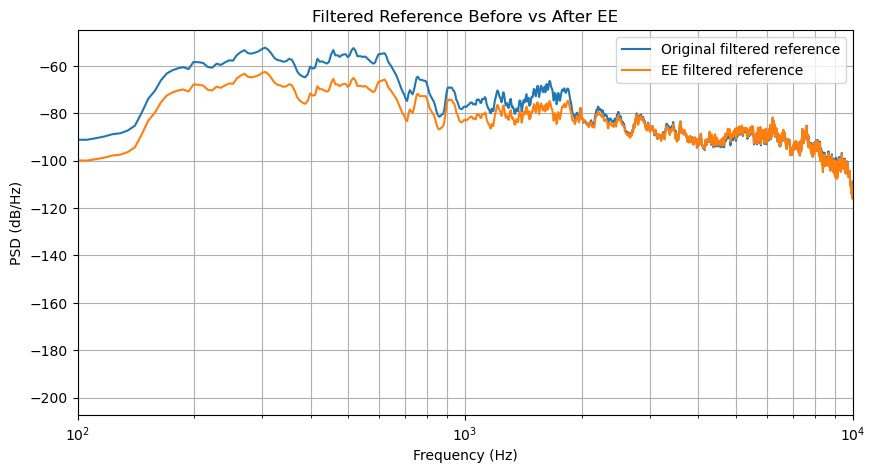

In [73]:
from scipy.signal import welch

f, P_orig = welch(xf_orig, fs=fs, nperseg=16384)
_, P_ee   = welch(xf_ee,   fs=fs, nperseg=16384)

plt.figure(figsize=(10, 5))

plt.semilogx(
    f,
    10*np.log10(P_orig + 1e-20),
    label="Original filtered reference",
)

plt.semilogx(
    f,
    10*np.log10(P_ee + 1e-20),
    label="EE filtered reference",
)

plt.xlim(100, 10000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("Filtered Reference Before vs After EE")
plt.grid(True, which="both")
plt.legend()
plt.show()